# DS 6021 Intro to Predictive Modeling Lab 2: Linear Regression

## Fiona St. Clair

AI Disclosure: I used Claude AI to help with certain parts of the coding in the assignment, along with the workbooks from class. The reasoning and logic behind my answers was written by me :)
***

## Part 1: Parameter Estimation and Model Fitting (8 pts) 
For this part of the activity, we want to predict body mass (body_mass_g) from bill depth (bill_depth_mm). 
 
- a. [2 pts] Create a scatterplot of bill_depth_mm vs. body_mass_g with a fitted regression line. Describe the direction and strength of the relationship. Is the direction what you would have expected? 

**The relationship between body mass and bill depth is inverse/negative, meaning as one grows, the other tends to shrink. It is not a very strong relationship, however, as most of the points do not fall near the best fit line, and there is clear clustering occuring, suggesting come sort of third relationship between the data. This is the opposite of the relationship I would have expected, but in all fairness, I do not know much about penguin growth.**

In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

<Axes: xlabel='bill_depth_mm', ylabel='body_mass_g'>

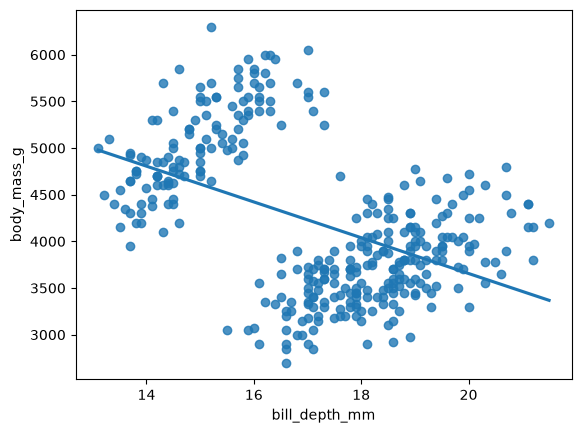

In [2]:
penguins = pd.read_csv('../../../data/penguins.csv')
sns.regplot(data=penguins, x="bill_depth_mm", y="body_mass_g", ci=None)

- b. [3 pts] Using only numpy and/or pandas — no sklearn, no statsmodels — compute B₀ and B₁ from the ordinary least squares formulas we derived in class. Report the estimated regression equation, and interpret the slope in the units of the data in one sentence. 

**b0 = 22.034**
**b1 = -0.001**

**So, Y = 22.034 - 0.001X**

**For every one-unit increase in body mass (x), bill depth (y) is predicted to decrease by 0.001 units, on average.**

In [3]:
# pandas method

x_mean = penguins["body_mass_g"].mean()
y_mean = penguins["bill_depth_mm"].mean()

beta1 = ((penguins["body_mass_g"] - x_mean) * (penguins["bill_depth_mm"] - y_mean)).sum() / ((penguins["body_mass_g"] - x_mean) ** 2).sum()
beta0 = y_mean - beta1 * x_mean

print(beta0,beta1) # B0 = 22.033946488573008   B1 = -0.0011620805143298324

22.033946488573008 -0.0011620805143298324


- c. [3 pts] Calculate RSE using the formula we discussed in class (see slide 35). Also calculate R2 by first calculating the correlation between bill depth and body mass. What are each of these numbers telling you? 

**An RSE of 4255.758 means that, on average, this model's predication for body mass is incorrecy by ~ 4256 grams. A correlation/r of -0.472 means that there is a moderate negative correlation between bill depth and body mass (as seen on our plot). An r squared of 0.233 means that only about 22.3% of the variation in body mass can be explained by bill depth, further suggesting other variables at play/**

In [4]:
# rse

import numpy as np

x = penguins["bill_depth_mm"]
y = penguins["body_mass_g"]

y_hat = beta0 + beta1 * x

RSS = np.sum((y - y_hat) ** 2)

n = len(penguins)
RSE = np.sqrt(RSS / (n - 2))

print("rse:", RSE) # 4255.75826499818

# R2 by calculating the correlation between bill depth and body mass

r = penguins["bill_depth_mm"].corr(penguins["body_mass_g"])

R2 = r ** 2

print("corr:", r)
print("r squared:", R2)

rse: 4255.75826499818
corr: -0.47191562118606645
r squared: 0.22270435351943096


***

## Part 2: How Good Is This Model? (12 pts) 

- a. [2 pts] Now use statsmodels to predict body mass from bill depth. For the slope (B₁), note the standard error, t-statistic, and p-value. State the null and alternative hypotheses that this t-test is evaluating, and what you can conclude based on these numbers. 

**For b1 bill depth, standard error = 19.417, t-statistic = -9.87, and p-value = 0.000. Our null hypothesis is bill depth has no linear effect on body mass (slope = 0), and our alternative hypothesis is bill depth does have a linear effect on body mass (slope =/ 0). Because our p-value is less than 0.05, we can conclude that there is a linear relationsuip between bill depth and body mass, but there could still be other variables at play.**

In [5]:
# getting rid of NaN values first

penguins_clean = penguins.dropna(subset=["bill_depth_mm", "body_mass_g"])

In [6]:
import statsmodels.api as sm

x = penguins_clean["bill_depth_mm"]
y = penguins_clean["body_mass_g"]

X = sm.add_constant(x)
model = sm.OLS(y, X).fit()

print(model.summary())

                            OLS Regression Results                            
Dep. Variable:            body_mass_g   R-squared:                       0.223
Model:                            OLS   Adj. R-squared:                  0.220
Method:                 Least Squares   F-statistic:                     97.41
Date:                Sat, 12 Sep 2026   Prob (F-statistic):           2.28e-20
Time:                        22:19:02   Log-Likelihood:                -2728.7
No. Observations:                 342   AIC:                             5461.
Df Residuals:                     340   BIC:                             5469.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                    coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------
const          7488.6524    335.218     22.340

b. [3 pts] Now look specifically at the R² for this model and the p-value for the slope. Discuss what each of these numbers is measuring, what they are collectively telling you, and how the information you are seeing from each is consistent.  

**Because the r squared is so small, this suggests that, even though there IS a relationship between body mass and bill depth (p value < 0.05), this relationship is quite weak because only ~22% of the variation can be explained by this relationship. Together, these suggest that, even though a relationship between the variables can be statistically significant, it is weak in practical application.**

c. [7 pts] Bootstrap the coefficients as we did in class: resample the rows with replacement 10,000 times, calculate B₀ and B₁ each resample, and report the 2.5th and 97.5th percentiles of each as well as the corresponding confidence interval. Compare these to the 95% confidence intervals statsmodels reports.  

**Using flipper length to predict body mass, the full-sample OLS estimates are beta 0 of 7488.65 and a beta 1 of -191.64. The bootstrap produces very similar results...the mean of the 10,000 resampled estimates is beta zero of 7496.02 and beta 1 of -192.06.**

**For beta 0, the analytic (formula-based) 95% CI is (6829.29, 8148.01), while the bootstrap 95% CI is (6959.09, 8059.26). For beta 1, the analytic CI is (-229.84, -153.45), while the bootstrap CI is (-223.88, -161.91).**

**The two methods are very similar in results with the bootstrap intervals sitting almost entirely within the origional intervals, just slightly narrower on the ends. This tells us that the bootstrap and the classical formula-based approach are producing consistent estimates of uncertainty for both coefficients. This suggests the standard OLS assumptions are well satisfied in this example.**

In [7]:
penguins_clean['y_hat'] = y_hat
penguins_clean['residuals'] = penguins_clean['body_mass_g'] - penguins_clean['y_hat']

penguins_clean[['body_mass_g', 'y_hat', 'residuals']].head()

,body_mass_g,y_hat,residuals
0,3750.0,22.012216,3727.987784
1,3800.0,22.013726,3777.986274
2,3250.0,22.013029,3227.986971
4,3450.0,22.011518,3427.988482
5,3650.0,22.010008,3627.989992


In [8]:
X = sm.add_constant(x)  # x = penguins_clean['flipper_length_mm']
results = sm.OLS(y, X).fit()
beta0, beta1 = results.params

rng = np.random.default_rng(42) # seed so class results are reproducible
n_boot = 10000
n = len(penguins_clean) # number of samples in each simulation

# We will use x and y as defined above and convert to numpy. 
x = penguins_clean['bill_depth_mm']
y = penguins_clean['body_mass_g']
xv, yv = x.to_numpy(), y.to_numpy()
boot = np.empty((n_boot, 2)) #initialize an array of empty tuples

In [9]:
for i in range(n_boot):                  # Do this 10000 times
    idx = rng.integers(0, n, n)          # sample n rows WITH replacement
    xb, yb = xv[idx], yv[idx]            # generate pairs of x and y from dataset
    xm, ym = xb.mean(), yb.mean()        # calculate means
    slope = ((xb - xm) * (yb - ym)).sum() / ((xb - xm) ** 2).sum() #calculate b1
    boot[i] = (ym - slope * xm, slope)   # save b0 and b1 for this simulation

In [10]:
results = sm.OLS(y, X).fit()

boot_df = pd.DataFrame(boot, columns=['b0', 'b1'])

# The 95% confidence interval is given by the middle 95% of this distribution
# We can use the quantile function to find this
# We can also compare with the values from statsmodels

analytic_ci = results.conf_int()

comparison = pd.DataFrame({
    'estimate (full sample)': [beta0, beta1],
    'bootstrap mean':         [boot_df['b0'].mean(), boot_df['b1'].mean()],
    'CI low (formula)':       analytic_ci[0].to_numpy(),
    'CI low (bootstrap)':     [boot_df['b0'].quantile(.025), boot_df['b1'].quantile(.025)],
    'CI high (formula)':      analytic_ci[1].to_numpy(),
    'CI high (bootstrap)':    [boot_df['b0'].quantile(.975), boot_df['b1'].quantile(.975)],
}, index=['b0', 'b1'])

comparison.round(3).T

,b0,b1
estimate (full sample),7488.652,-191.643
bootstrap mean,7496.018,-192.057
CI low (formula),6829.290,-229.835
CI low (bootstrap),6959.090,-223.878
CI high (formula),8148.014,-153.450
CI high (bootstrap),8059.257,-161.913


c-a. Which gives narrower confidence intervals, statsmodels or the bootstrap? What does that tell you?  

**For beta 0, the analytic (formula-based) 95% CI is (6829.29, 8148.01), while the bootstrap 95% CI is (6959.09, 8059.26). For beta 1, the analytic CI is (-229.84, -153.45), while the bootstrap CI is (-223.88, -161.91).**

**This suggests the bootstrap estimates slightly less uncertainty than the formula does. The formula-based intervals rely on assumptions like normally distributed residuals, and when those assumptions aren't perfectly met, they tend to be a bit wider. The bootstrap doesn't rely on those assumptions so its tighter intervals better reflect the real uncertainty in this dataset.**

c-b. What assumption does the formula-based interval make that the bootstrap does not? 

**The formula-based interval assumes the residuals are normally distributed have constant variance across all values of x. This assumption is what lets statsmodels use the t-distribution to construct its confidence intervals mathematically.**

c-c&d. Change the random seed (or unset it, so it is different each time) and run the bootstrap 10 times with B=100. Repeat this for B=1000 and B=10000. (Note: B=10000 in the original question. It is the number of times you repeat the bootstrap simulation.) For each of these simulations, look at the 2.5th and 97.5th percentiles and view them in a table. You basically want to compare the 95% confidence intervals for each of the 10 simulations at each value of B. What information does this give you about the value of B in your bootstrap simulation?

**As B increases from 100 to 1000 to 10000, the confidence interval bounds become more consistent across the 10 runs and the standard deviations shrink each time. This shows that with a small B, the bootstrap results are less stable, as different random seeds give noticeably different CIs. With a larger B, the results become nearly identical across runs. So a bigger B gives more reliable, reproducible confidence intervals, though the improvement gets smaller each time you increase B.**

In [11]:
# Used Claude AI to help me with replicating the above lines into multiple iterations and then a summary table. 

def run_bootstrap(xv, yv, n_boot, seed=None):
    rng = np.random.default_rng(seed)  
    n = len(xv)
    boot = np.empty((n_boot, 2))
    for i in range(n_boot):
        idx = rng.integers(0, n, n)
        xb, yb = xv[idx], yv[idx]
        xm, ym = xb.mean(), yb.mean()
        slope = ((xb - xm) * (yb - ym)).sum() / ((xb - xm) ** 2).sum()
        boot[i] = (ym - slope * xm, slope)
    return boot

x = penguins_clean['flipper_length_mm'].to_numpy()
y = penguins_clean['body_mass_g'].to_numpy()

results_table = []

for B in [100, 1000, 10000]:
    for run in range(10):
        boot = run_bootstrap(x, y, B, seed=None)  
        b0_low, b0_high = np.percentile(boot[:, 0], [2.5, 97.5])
        b1_low, b1_high = np.percentile(boot[:, 1], [2.5, 97.5])
        results_table.append({
            'B': B,
            'run': run + 1,
            'b0_low': b0_low,
            'b0_high': b0_high,
            'b1_low': b1_low,
            'b1_high': b1_high
        })

results_df = pd.DataFrame(results_table)

In [12]:
summary = results_df.groupby('B')[['b0_low', 'b0_high', 'b1_low', 'b1_high']].agg(['mean', 'std'])
summary.round(3)

b0_low           b0_high           b1_low        b1_high       
           mean     std      mean      std    mean    std    mean    std
B                                                                       
100   -6374.363  78.078 -5239.484  105.549  47.054  0.512  52.616  0.389
1000  -6366.617  24.955 -5214.450   39.106  46.873  0.180  52.571  0.119
10000 -6359.131   6.805 -5210.013    6.824  46.872  0.032  52.526  0.030

***

## Part 3: Residuals (12 pts) 

a. [3 pts] Plot fitted values vs. residuals for your bill depth model you just built. Please also replicate the fitted vs residuals plot we looked at in class for the model predicting mass as a function of flipper length. Compare these plots side by side. What is each of these plots telling you about the respective models?  

**The two residual plots are noticeably different. The flipper length model's residuals are scattered fairly randomly around zero across the range of fitted values, with no strong pattern, consistent with the linear model assumptions being reasonably well met, and supports flipper length being a better linear predictor of body mass than bill depth. In contrast, the bill depth model's residuals show a clear non-random structure...rather than scattering randomly, the points seem to form diagonal bands or clusters that don't hover consistently around zero across the fitted range. This pattern suggests that a simple linear model with bill depth alone is missing something important, most likely species. This is consistent with the earlier finding that bill depth had a much lower r squared than would be expected for flipper length (the relationship isn't just weak, it's also not well-modeled by a single straight line across all penguins).**

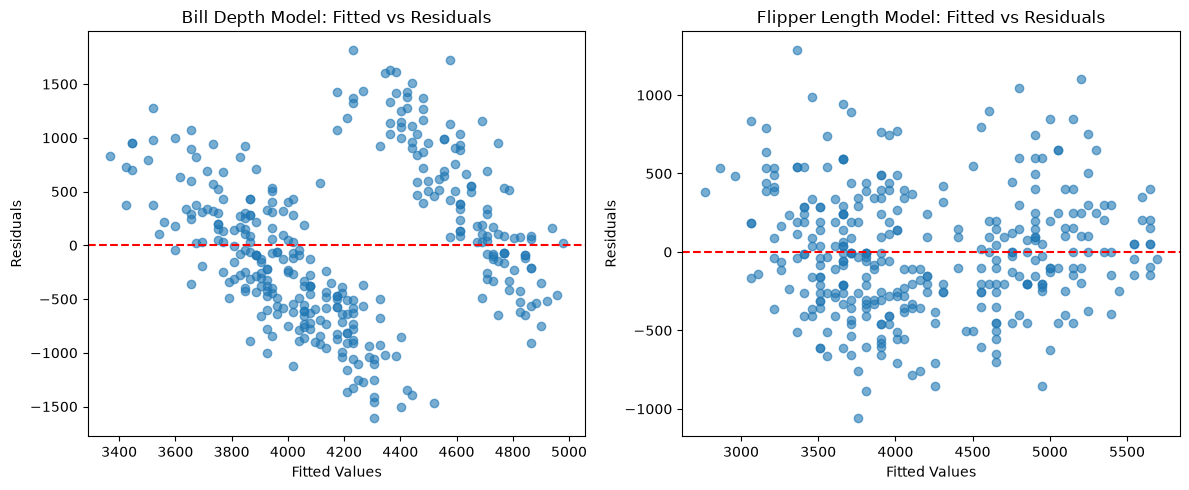

In [13]:
# used Claude AI to help make the two graphs side by side 

# --- Model 1: bill depth predicting body mass ---
x1 = penguins_clean['bill_depth_mm']
y = penguins_clean['body_mass_g']
X1 = sm.add_constant(x1)
model1 = sm.OLS(y, X1).fit()
fitted1 = model1.fittedvalues
resid1 = model1.resid

# --- Model 2: flipper length predicting body mass ---
x2 = penguins_clean['flipper_length_mm']
X2 = sm.add_constant(x2)
model2 = sm.OLS(y, X2).fit()
fitted2 = model2.fittedvalues
resid2 = model2.resid

# --- Plot side by side ---
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].scatter(fitted1, resid1, alpha=0.6)
axes[0].axhline(0, color='red', linestyle='--')
axes[0].set_xlabel('Fitted Values')
axes[0].set_ylabel('Residuals')
axes[0].set_title('Bill Depth Model: Fitted vs Residuals')

axes[1].scatter(fitted2, resid2, alpha=0.6)
axes[1].axhline(0, color='red', linestyle='--')
axes[1].set_xlabel('Fitted Values')
axes[1].set_ylabel('Residuals')
axes[1].set_title('Flipper Length Model: Fitted vs Residuals')

plt.tight_layout()
plt.show()

b. [2 pts] Then plot the same residuals again, colored by species. Describe what you see in each. 

**Both models show the same species pattern: Gentoo (orange) clusters at the higher end of fitted values, while Adelie and Chinstrap overlap heavily with each other at the lower end, in both the bill depth and flipper length plots. This means species is acting as a confounding variable in both models, not just the bill depth one. Additionally, a lot of the apparent relationship between the predictor and body mass is really just reflecting the fact that Gentoo penguins are larger overall.**

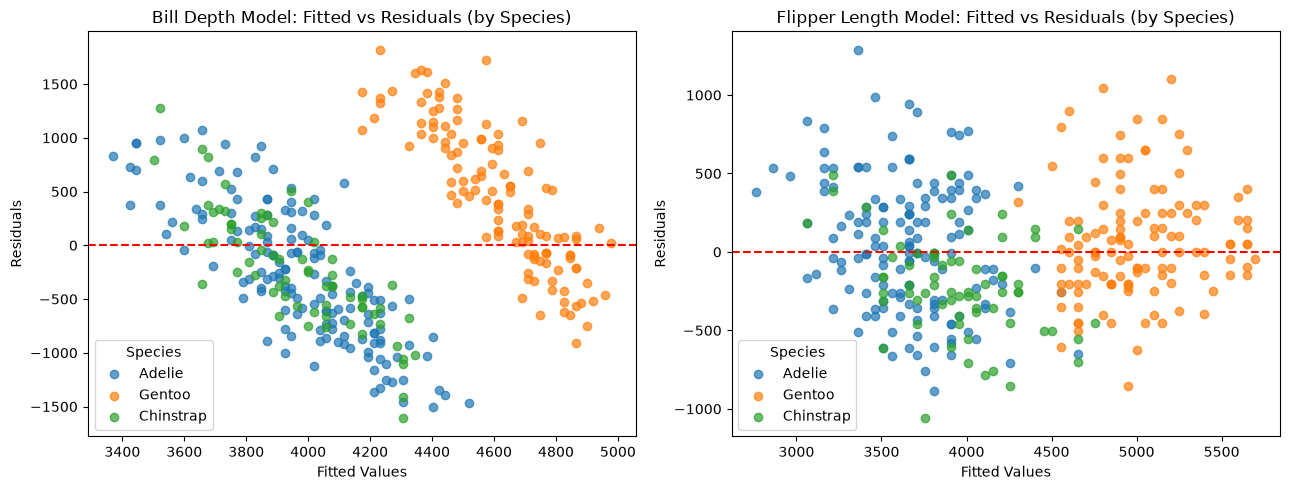

In [14]:
# used Claude AI to help make the two graphs side by side 

species = penguins_clean['species']

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Bill depth model, colored by species
for sp in species.unique():
    mask = species == sp
    axes[0].scatter(fitted1[mask], resid1[mask], alpha=0.7, label=sp)
axes[0].axhline(0, color='red', linestyle='--')
axes[0].set_xlabel('Fitted Values')
axes[0].set_ylabel('Residuals')
axes[0].set_title('Bill Depth Model: Fitted vs Residuals (by Species)')
axes[0].legend(title='Species')

# Flipper length model, colored by species
for sp in species.unique():
    mask = species == sp
    axes[1].scatter(fitted2[mask], resid2[mask], alpha=0.7, label=sp)
axes[1].axhline(0, color='red', linestyle='--')
axes[1].set_xlabel('Fitted Values')
axes[1].set_ylabel('Residuals')
axes[1].set_title('Flipper Length Model: Fitted vs Residuals (by Species)')
axes[1].legend(title='Species')

plt.tight_layout()
plt.show()

c-a. [2 pts] Compute the correlation between bill_depth_mm and body_mass_g  

across all penguins and  

In [15]:
corr_all = penguins_clean['bill_depth_mm'].corr(penguins_clean['body_mass_g'])
print(f"Correlation across all penguins: {corr_all:.3f}")

Correlation across all penguins: -0.472


c-b. separately within each species.  

In [16]:
for sp in penguins_clean['species'].unique():
    subset = penguins_clean[penguins_clean['species'] == sp]
    corr_sp = subset['bill_depth_mm'].corr(subset['body_mass_g'])
    print(f"{sp}: correlation = {corr_sp:.3f}")

Adelie: correlation = 0.576
Gentoo: correlation = 0.719
Chinstrap: correlation = 0.604


c-c. Explain what is going on.  

**The correlation between bill depth and body mass is negative when all penguins are pooled together (-0.472), but positive within every individual species (Adelie: 0.576, Gentoo: 0.719, Chinstrap: 0.604). This happens because species is a confounding variable that is strongly related to both bill depth and body mass. Gentoo penguins tend to have the largest body mass but shallow bills, while Adelie and Chinstrap penguins have smaller body mass but comparatively deeper bills. This between-species difference is large enough to dominate and reverse the true within-species relationship, where bill depth and body mass are actually positively related once species is held constant. Pooling the species together masks the real underlying relationship and produces a misleading negative correlation.**

d. [5 pts] Build a linear model using bill depth to predict body mass using only data for the Adelie penguins. Create a plot of bill depth vs body mass as well as fitted vs residuals for this model. What conclusions would you draw for just the Adelies? Reflect on how this is related to the conclusions you drew for all penguins.  

**Within Adelie penguins alone, bill depth has a positive relationship with body mass (beta 1 = 217.15, p < 0.001), the opposite of the negative slope seen when all species are together. R squared is also higher (0.332 vs. 0.223), meaning bill depth explains more variation once species is held constant, and the residuals look randomly scattered with no banding pattern. This confirms the pooled model's negative relationship was due to of species differences (Gentoo being heavier but shallower-billed than Adelie/Chinstrap), and the true within-species relationship is actually positive.**

                            OLS Regression Results                            
Dep. Variable:            body_mass_g   R-squared:                       0.332
Model:                            OLS   Adj. R-squared:                  0.327
Method:                 Least Squares   F-statistic:                     74.03
Date:                Sat, 12 Sep 2026   Prob (F-statistic):           9.94e-15
Time:                        22:19:06   Log-Likelihood:                -1108.6
No. Observations:                 151   AIC:                             2221.
Df Residuals:                     149   BIC:                             2227.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                    coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------
const          -283.2787    464.033     -0.610

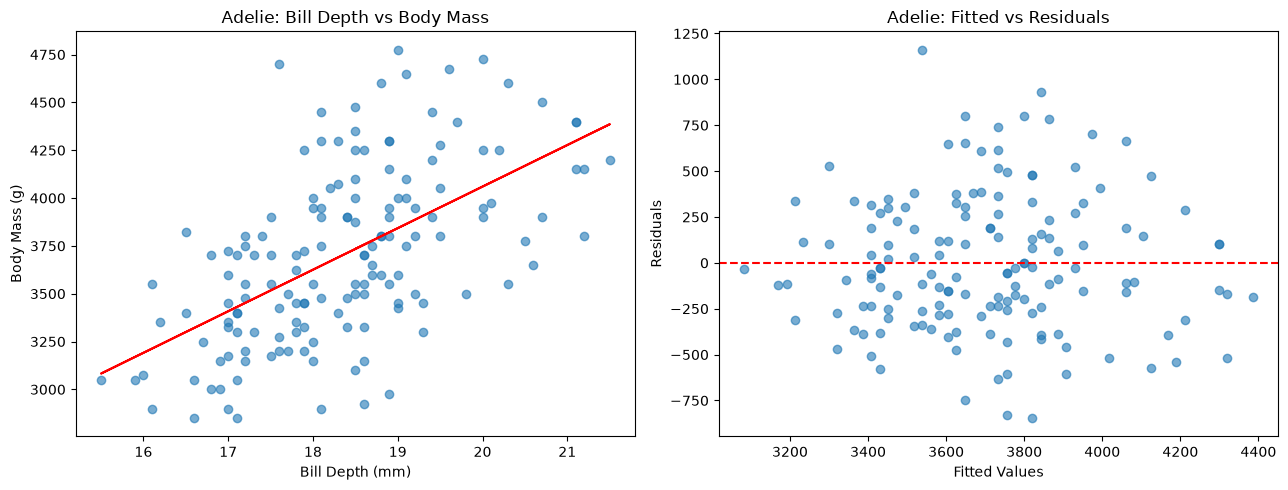

Beta0: -283.279, Beta1: 217.152
R2: 0.332
p-value for slope: 0.000000


In [ ]:
# used Claude AI to help make the two graphs side by side 

adelie = penguins_clean[penguins_clean['species'] == 'Adelie']

x_adelie = adelie['bill_depth_mm']
y_adelie = adelie['body_mass_g']

# Fit model
X_adelie = sm.add_constant(x_adelie)
model_adelie = sm.OLS(y_adelie, X_adelie).fit()
print(model_adelie.summary())

fitted_adelie = model_adelie.fittedvalues
resid_adelie = model_adelie.resid

# Plot 1: bill depth vs body mass, with fitted line
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

axes[0].scatter(x_adelie, y_adelie, alpha=0.6)
axes[0].plot(x_adelie, fitted_adelie, color='red')
axes[0].set_xlabel('Bill Depth (mm)')
axes[0].set_ylabel('Body Mass (g)')
axes[0].set_title('Adelie: Bill Depth vs Body Mass')

# Plot 2: fitted vs residuals
axes[1].scatter(fitted_adelie, resid_adelie, alpha=0.6)
axes[1].axhline(0, color='red', linestyle='--')
axes[1].set_xlabel('Fitted Values')
axes[1].set_ylabel('Residuals')
axes[1].set_title('Adelie: Fitted vs Residuals')

plt.tight_layout()
plt.show()

# Key numbers for your write-up
beta0_adelie, beta1_adelie = model_adelie.params
r2_adelie = model_adelie.rsquared
pval_adelie = model_adelie.pvalues['bill_depth_mm']

print(f"Beta0: {beta0_adelie:.3f}, Beta1: {beta1_adelie:.3f}")
print(f"R2: {r2_adelie:.3f}")
print(f"p-value for slope: {pval_adelie:.6f}")

***

## Part 4: Multiple Linear Regression (8 pts) 

For this question we will dive in a bit more deeply into the multiple linear regression models we started looking at during class.  

a. [2 pts] Look at the formulas of R2 and Adj R2 that we went over in class. Why do these two values behave differently? How does their behavior differ as more predictors are added. (Hint: The recommended reading will help with insight here as well.)  

**R squared will always stay the same or increase as more predictors are added, even if those predictors are irrelevant, because adding a variable can never increase RSS. Adjusted R squared corrects for this by penalizing the number of predictors relative to sample size, so it only increases when a new predictor improves the model enough to outweigh that penalty, or else it decreases, making it a better metric for comparing models with different numbers of predictors.**

b. [3 pts] Fit three models on the same rows, with body_mass_g as the response: 
    a. flipper_length_mm 
    b. flipper_length_mm + bill_depth_mm 
    c. flipper_length_mm + bill_depth_mm + bill_length_mm 
    d. For each of these models, create a table reporting R², adjusted R², RSE, and the F-statistic for each. Which model would you choose, and why?  

**I would choose model b, which includes flipper length and bill depth, because it has the highest adjusted r squared (0.7596) among all three models. While model c has a marginally higher r squared (0.7615 vs. 0.7610), its adjusted r squared is lower than model b's, and its RSE is also slightly higher, both signs that adding bill length doesn't meaningfully improve the model.**

In [ ]:
# Claude AI (and the notes) used to help me understand the coding behind this idea

cols_needed = ['flipper_length_mm', 'bill_depth_mm', 'bill_length_mm', 'body_mass_g']
df_model = penguins_clean.dropna(subset=cols_needed)

y = df_model['body_mass_g']

# Model a: flipper_length_mm
X_a = sm.add_constant(df_model[['flipper_length_mm']])
model_a = sm.OLS(y, X_a).fit()

# Model b: flipper_length_mm + bill_depth_mm
X_b = sm.add_constant(df_model[['flipper_length_mm', 'bill_depth_mm']])
model_b = sm.OLS(y, X_b).fit()

# Model c: flipper_length_mm + bill_depth_mm + bill_length_mm
X_c = sm.add_constant(df_model[['flipper_length_mm', 'bill_depth_mm', 'bill_length_mm']])
model_c = sm.OLS(y, X_c).fit()

# comparison table
results_table = pd.DataFrame({
    'Model': ['a: flipper', 'b: flipper + bill depth', 'c: flipper + bill depth + bill length'],
    'R2': [model_a.rsquared, model_b.rsquared, model_c.rsquared],
    'Adj R2': [model_a.rsquared_adj, model_b.rsquared_adj, model_c.rsquared_adj],
    'RSE': [
        np.sqrt(model_a.mse_resid),
        np.sqrt(model_b.mse_resid),
        np.sqrt(model_c.mse_resid)
    ],
    'F-statistic': [model_a.fvalue, model_b.fvalue, model_c.fvalue]
})

results_table.round(4)

,Model,R2,Adj R2,RSE,F-statistic
0,a: flipper,0.7590,0.7583,394.2782,1070.7446
1,b: flipper + bill depth,0.7610,0.7596,393.1784,539.8239
2,c: flipper + bill depth + bill length,0.7615,0.7594,393.4048,359.6718


c. [2 pts] In Part 1, the simple regression slope on bill depth was negative. Report the coefficient on bill_depth_mm in the second model above. What happened, and why? Use the interpretation of βⱼ from class — the average effect of a one unit increase in that predictor, holding the other predictors fixed — in your explanation. 

**The coefficient on bill_depth_mm in model b is 22.63, meaning that holding flipper length fixed, a one millimeter increase in bill depth has an average increase of about 22.63 grams in body mass, which is the opposite sign from the negative slope in part 1's simple regression. This happens because beta represents the effect of a predictor holding the others fixed...in part 1, bill depth's coefficient was confounded by species, which created a misleading negative relationship. Once flipper length is controlled for in model b, most of that species driven confounding is removed, revealing the true positive relationship between bill depth and body mass, consistent with the positive within-species correlations found in part 3.**

In [19]:
print(model_b.params)

const               -6541.907498
flipper_length_mm      51.541445
bill_depth_mm          22.634138
dtype: float64


d. [1 pt] State the null and alternative hypotheses tested by the F-statistic in the third model, and what you conclude from it.

**The f-statistic in model c tests the null hypothesis that none of the predictors have any linear relationship with body mass, and the alternative is that at least one of them does (at least one beta =/ 0). Since the f-statistic (359.67) is large and its p-value is essentially zero, we reject the null hypothesis and conclude that at least one predictor is significantly related to body mass, meaning the model as a whole is statistically meaningful, even though, as found in part b, not every individual predictor adds enough value to justify its inclusion.**

***

## Part 5: Modeling with the Planets Dataset (10 pts) 

For this part, switch to PlanetsData.csv, which gives each planet's mean distance from the sun (in millions of miles) and its orbital period, or revolution (in Earth days). 

a. [2 pt] Fit an OLS model predicting revolution from distance and report R². Judging by R² alone, how good does this model look? Compare actual and predicted values for each of the planets. Now look at the predicted revolution for the four innermost planets? What does that tell you? 

**This model predicting revolution from distance has an r squared of 0.978, which at first glance suggests an great fit. However, comparing actual and predicted values reveals a problem: for the four innermost planets (Mercury, Venus, Earth, Mars), the model predicts negative revolutions (e.g., roughly -3711 days for Mercury, whose actual revolution is 88 days) which is physically impossibile. This shows that r squared alone can be misleading. Since the outer planets have much larger distances and revolutions, they dominate the sum of squares that r squared is based on, making the fit look very strong overall even though the linear model fails to capture the true relationship for the smaller, inner planets. This is because the actual relationship between distance and revolution isn't linear.**

In [20]:
planets = pd.read_csv('../../../data/PlanetsData.csv') 
print(planets.head())

x = planets['distance']
y = planets['revolution']

X = sm.add_constant(x)
model = sm.OLS(y, X).fit()
print(model.summary())

r2 = model.rsquared
print(f"R2: {r2:.4f}")

comparison = pd.DataFrame({
    'planet': planets['planet'],  
    'distance': x,
    'actual_revolution': y,
    'predicted_revolution': model.fittedvalues
})
comparison

    planet  distance  diameter  revolution  position
0  Mercury        36      3030          88         1
1    Venus        67      7520         225         2
2    Earth        93      7926         365         3
3     Mars       142      4217         687         4
4  Jupiter       484     88838        4332         5
                            OLS Regression Results                            
Dep. Variable:             revolution   R-squared:                       0.978
Model:                            OLS   Adj. R-squared:                  0.975
Method:                 Least Squares   F-statistic:                     312.1
Date:                Sat, 12 Sep 2026   Prob (F-statistic):           4.59e-07
Time:                        22:19:07   Log-Likelihood:                -88.599
No. Observations:                   9   AIC:                             181.2
Df Residuals:                       7   BIC:                             181.6
Df Model:                           1             

,planet,distance,actual_revolution,predicted_revolution
0,Mercury,36,88,-3711.348645
1,Venus,67,225,-2964.382280
2,Earth,93,365,-2337.894361
3,Mars,142,687,-1157.205590
4,Jupiter,484,4332,7083.520113
5,Saturn,887,10760,16794.082858
6,Uranus,1765,30684,37950.097969
7,Neptune,2791,60188,62672.275081
8,Pluto,3654,90467,83466.854854


b. [2 pts] Plot fitted values vs. residuals for this model. What do you see? Which planets have the largest residuals, and in which direction? What does this tell you about the validity of the linear 
model for this dataset?  

**The four innermost planets (Mercury, Venus, Earth, Mars) all have large positive residuals, meaning the model badly underpredicted their revolutions. The middle planets (Jupiter, Saturn, Uranus, Neptune) all have large negative residuals, meaning the model overpredicted theirs. Then it swings back positive for Pluto, which has the largest residual of all. This U-shaped pattern tells us the linear model doesn't work for this data and it's missing real structure in the relationship between distance and revolution.**

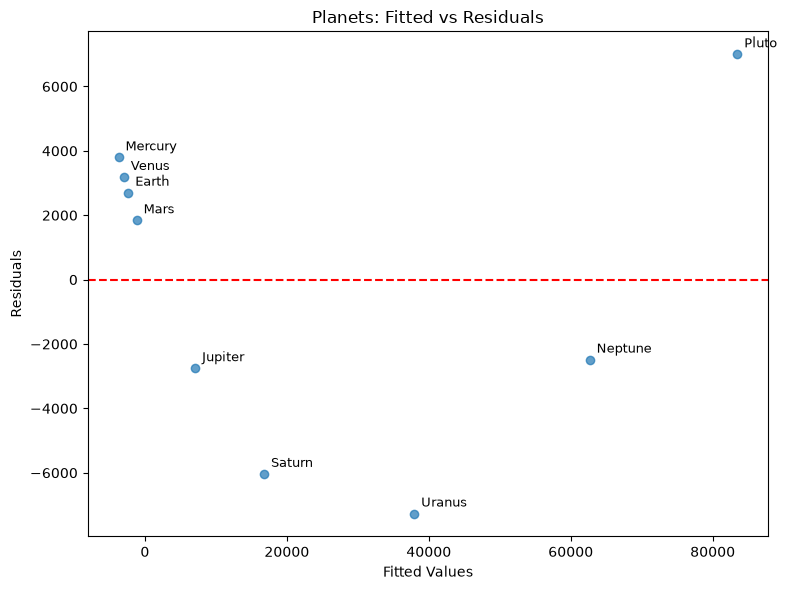

In [21]:
fitted = model.fittedvalues
resid = model.resid

plt.figure(figsize=(8, 6))
plt.scatter(fitted, resid, alpha=0.7)
plt.axhline(0, color='red', linestyle='--')
plt.xlabel('Fitted Values')
plt.ylabel('Residuals')
plt.title('Planets: Fitted vs Residuals')

#  planet name labels
for i, name in enumerate(planets['planet']):
    plt.annotate(name, (fitted.iloc[i], resid.iloc[i]),
                 textcoords="offset points", xytext=(5, 5), fontsize=9)

plt.tight_layout()
plt.show()

c-a.[6 pts] One approach that we will discuss further in the coming weeks is transforming variables in order to improve the performance of regression models. We will try that here.  

Apply a log transformation to both distance and revolution and refit the model. This means you will build a linear model with the x variable being log(distance) and the y variable being log(revolution).  

In [22]:
planets['log_distance'] = np.log(planets['distance'])
planets['log_revolution'] = np.log(planets['revolution'])

x_log = planets['log_distance']
y_log = planets['log_revolution']

X_log = sm.add_constant(x_log)
model_log = sm.OLS(y_log, X_log).fit()

print(model_log.summary())

r2_log = model_log.rsquared
print(f"R2 (log-log model): {r2_log:.4f}")

                            OLS Regression Results                            
Dep. Variable:         log_revolution   R-squared:                       1.000
Model:                            OLS   Adj. R-squared:                  1.000
Method:                 Least Squares   F-statistic:                 1.585e+06
Date:                Sat, 12 Sep 2026   Prob (F-statistic):           5.26e-20
Time:                        22:19:07   Log-Likelihood:                 34.696
No. Observations:                   9   AIC:                            -65.39
Df Residuals:                       7   BIC:                            -65.00
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                   coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------
const           -0.9031      0.007   -122.147   

c-b. Plot log(distance) vs log(revolution) as well as fitted vs residuals for this model. Compare this to the model you built in part a. Is this a better fit?  

**The log-log model is a far better fit than the original model. The left plot shows log(distance) and log(revolution) falling almost perfectly on a straight line, unlike the strongly curved relationship in the raw data. The right plot's residuals are now tiny and show no clear pattern with Uranus and Venus as the largest outliers but nowhere near the scale of the original model's errors. This is a much better and more valid model than the untransformed version.**

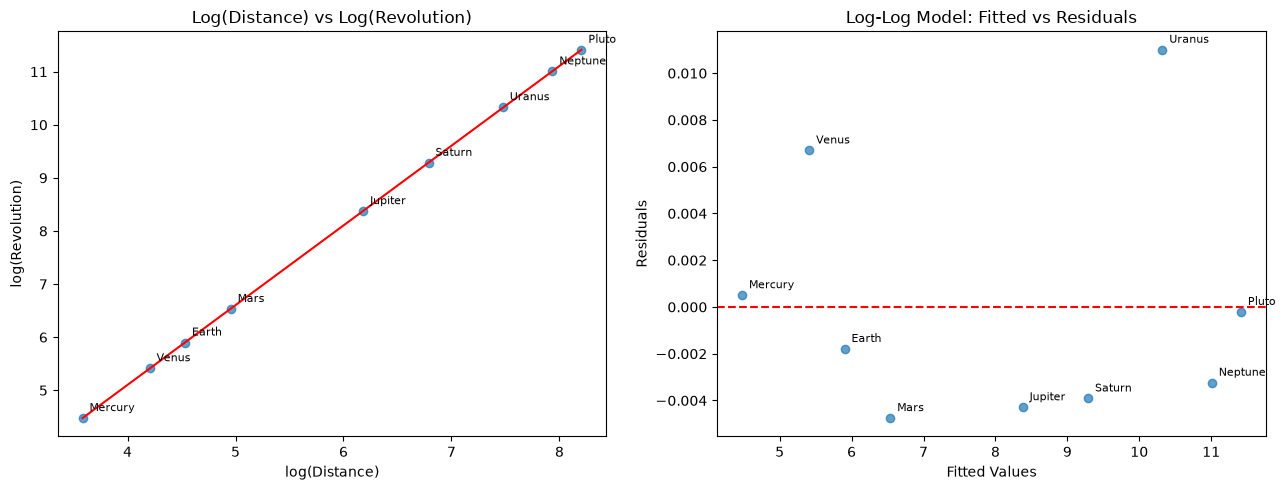

In [23]:
fitted_log = model_log.fittedvalues
resid_log = model_log.resid

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Plot 1: log(distance) vs log(revolution), with fitted line
axes[0].scatter(x_log, y_log, alpha=0.7)
axes[0].plot(x_log, fitted_log, color='red')
for i, name in enumerate(planets['planet']):
    axes[0].annotate(name, (x_log.iloc[i], y_log.iloc[i]),
                      textcoords="offset points", xytext=(5, 5), fontsize=8)
axes[0].set_xlabel('log(Distance)')
axes[0].set_ylabel('log(Revolution)')
axes[0].set_title('Log(Distance) vs Log(Revolution)')

# Plot 2: fitted vs residuals
axes[1].scatter(fitted_log, resid_log, alpha=0.7)
axes[1].axhline(0, color='red', linestyle='--')
for i, name in enumerate(planets['planet']):
    axes[1].annotate(name, (fitted_log.iloc[i], resid_log.iloc[i]),
                      textcoords="offset points", xytext=(5, 5), fontsize=8)
axes[1].set_xlabel('Fitted Values')
axes[1].set_ylabel('Residuals')
axes[1].set_title('Log-Log Model: Fitted vs Residuals')

plt.tight_layout()
plt.show()

c-c. Report the new R² and the estimated slope. The slope should land very close to a simple fraction — what is it? Using this simple fraction and algebra on your fitted equation, show that this implies Kepler’s third law of planetary motion: revolution² ∝ distance³ 

**The log-log model has an r squared of 1.00 and an estimated slope of 1.50, which lands almost exactly on the simple fraction 3/2.**

**Starting from the fitted equation:**

    log(revolution) = -0.9031 + (3/2) * log(distance)

**Exponentiating both sides (raising e to the power of each side to undo the log) gives:**

    revolution = e^(-0.9031) * distance^(3/2)

**If k = e^(-0.9031). Then:**

    revolution = k * distance^(3/2)

**Squaring both sides:**

    revolution^2 = k^2 * distance^3

**Since k^2 is just another constant, this shows:**

    revolution^2 ∝ distance^3

**The square of a planet's orbital period is proportional to the cube of its distance from the sun. The near-perfect r squared of 1.00 and the slope landing almost exactly on 3/2 confirm that the log transformation shows this true underlying relationship.**

In [24]:
slope_log = model_log.params['log_distance']
intercept_log = model_log.params['const']
r2_log = model_log.rsquared

print(f"Slope: {slope_log:.4f}")
print(f"Intercept: {intercept_log:.4f}")
print(f"R2: {r2_log:.4f}")

Slope: 1.5013
Intercept: -0.9031
R2: 1.0000


c-d. With this new equation, create a table of actual vs fitted values for revolution for each planet. How close is the new model to reality vs the linear model?

**The log-log model's predicted revolutions are very close to the actual values for every planet, including Mercury, Venus, Earth, and Mars, which were the same planets where the linear model predicted impossible negative revolutions. This shows the log-log model is much more accurate in practice: the linear model had a high r squared (0.978) but bad real-world predictions, while the log-log model (r squared = 1.00) predicts values close to reality across every planet.**

In [25]:
predicted_log_revolution = model_log.fittedvalues
predicted_revolution = np.exp(predicted_log_revolution)

comparison_log = pd.DataFrame({
    'planet': planets['planet'],
    'distance': planets['distance'],
    'actual_revolution': planets['revolution'],
    'predicted_revolution_loglog': predicted_revolution.round(2),
    'predicted_revolution_linear': model.fittedvalues.round(2) 
})

comparison_log

,planet,distance,actual_revolution,predicted_revolution_loglog,predicted_revolution_linear
0,Mercury,36,88,87.96,-3711.35
1,Venus,67,225,223.50,-2964.38
2,Earth,93,365,365.66,-2337.89
3,Mars,142,687,690.27,-1157.21
4,Jupiter,484,4332,4350.62,7083.52
5,Saturn,887,10760,10802.20,16794.08
6,Uranus,1765,30684,30348.27,37950.10
7,Neptune,2791,60188,60383.24,62672.28
8,Pluto,3654,90467,90486.17,83466.85
